# Baseline de Modelo XGBoost

**Objetivo:** Entrenar un primer modelo XGBoost con parámetros por defecto para establecer un rendimiento de referencia (baseline) en el dataset espacial. Sirve como punto de partida antes de la optimización de hiperparámetros.

**Entrada:**
- `data/processed/X_train.csv`, `y_train.csv`
- `data/processed/X_val.csv`, `y_val.csv`
- `data/processed/X_test.csv`, `y_test.csv`

**Salida:**
- **Logs de Consola**: Métricas de rendimiento (AUC, F1-Score, RMSE, MAE) para el modelo XGBoost base en los conjuntos de validación y prueba.
- **Visualizaciones**: Curvas de aprendizaje que muestran cómo evoluciona el error del modelo durante el entrenamiento.

# Baseline XGBoost (Spatial Panel)

Train a baseline XGBoost regressor on the spatial panel dataset (train/test splits).

In [2]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

base_dir = Path.cwd()
for root in [base_dir, *base_dir.parents]:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break

from src.data_processing.build_dataset import get_training_features

## 1. Carga de datos
Carga los splits desde data/splits y prepara targets de retorno (regresion y clasificacion).

In [3]:
dataset_path = None
for root in [base_dir, *base_dir.parents]:
    candidate = root / "data" / "processed" / "dataset_entrenamiento_final.csv"
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError("dataset_entrenamiento_final.csv not found under data/processed")

df = pd.read_csv(dataset_path, parse_dates=["date"])
print("dataset:", dataset_path.resolve())
print("shape:", df.shape)

target_cols = sorted(
    [c for c in df.columns if c.startswith("precio_provincial_TARGET_H")],
    key=lambda c: int(c.split("_H")[-1])
)
if "precio_provincial_TARGET_H1" not in target_cols:
    raise ValueError("Missing precio_provincial_TARGET_H1 in dataset")

horizons = [int(c.split("_H")[-1]) for c in target_cols]

identifiers = ["date", "provincia", "cereal_predominante"]
training_cols = get_training_features(df)
feature_cols = [
    c for c in training_cols
    if c in df.columns and c not in identifiers + target_cols
]

X_full = df[feature_cols].copy()
bool_cols = X_full.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X_full[bool_cols] = X_full[bool_cols].astype(int)

cat_cols = X_full.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)

split_date = pd.Timestamp("2021-01-01")
train_mask = df["date"] < split_date
test_mask = ~train_mask

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

X_train = X_full.loc[train_mask].copy()
X_test = X_full.loc[test_mask].copy()
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

base_price_col = "precio_provincial_lag_1" if "precio_provincial_lag_1" in df.columns else None

print("horizons:", horizons)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("base_price_col:", base_price_col)

dataset: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\processed\dataset_entrenamiento_final.csv
shape: (7047, 76)
horizons: [1]
X_train shape: (5394, 77)
X_test shape: (1653, 77)
base_price_col: precio_provincial_lag_1


## 2. Entrenamiento del modelo (XGBoost Baseline)
Dos modelos: regresion (retorno) y clasificacion (direccion).

In [4]:
warnings.filterwarnings("ignore")

reg_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 5.0,
    "random_state": 42,
}

reg_models = {}
preds_reg = {}
y_test_map = {}
base_test_map = {}
metrics_rows = []

for h, target_col in zip(horizons, target_cols):
    train_mask_h = train_df[target_col].notna()
    test_mask_h = test_df[target_col].notna()

    X_train_h = X_train.loc[train_mask_h]
    y_train = train_df.loc[train_mask_h, target_col]
    X_test_h = X_test.loc[test_mask_h]
    y_test = test_df.loc[test_mask_h, target_col]

    model = XGBRegressor(**reg_params)
    model.fit(X_train_h, y_train)

    pred = model.predict(X_test_h)

    reg_models[h] = model
    preds_reg[h] = pd.Series(pred, index=y_test.index)
    y_test_map[h] = y_test

    base_prices = None
    if base_price_col and base_price_col in test_df.columns:
        base_prices = test_df.loc[test_mask_h, base_price_col]
    base_test_map[h] = base_prices

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    if y_test.nunique() > 1:
        pearson = pearsonr(y_test, pred)[0]
    else:
        pearson = np.nan

    if base_prices is not None:
        dir_acc = (np.sign(pred - base_prices) == np.sign(y_test - base_prices)).mean()
    else:
        dir_acc = np.nan

    metrics_rows.append({
        "horizon": h,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "DirectionalAcc": float(dir_acc) if dir_acc == dir_acc else np.nan,
        "Pearson": float(pearson) if pearson == pearson else np.nan,
        "n_test": int(test_mask_h.sum()),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("horizon")
metrics_df

,horizon,MAE,RMSE,DirectionalAcc,Pearson,n_test
0,1,5.049961,7.010997,0.60859,0.62088,1653


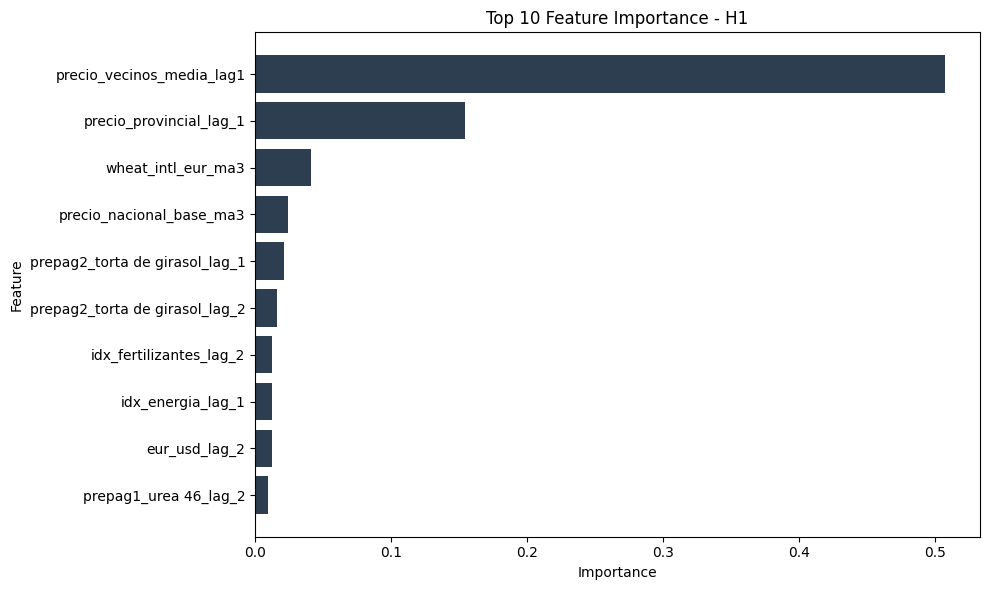

,horizon,rank,feature,importance
0,1,1,precio_vecinos_media_lag1,0.507978
1,1,2,precio_provincial_lag_1,0.154171
2,1,3,wheat_intl_eur_ma3,0.040744
3,1,4,precio_nacional_base_ma3,0.024277
4,1,5,prepag2_torta de girasol_lag_1,0.021176
5,1,6,prepag2_torta de girasol_lag_2,0.016359
6,1,7,idx_fertilizantes_lag_2,0.012647
7,1,8,idx_energia_lag_1,0.012502
8,1,9,eur_usd_lag_2,0.012083
9,1,10,prepag1_urea 46_lag_2,0.009575


In [5]:
feature_importance_rows = []
top_features_map = {}

for h in horizons:
    model = reg_models.get(h)
    importances = getattr(model, "feature_importances_", None) if model else None
    if importances is None:
        continue

    order = np.argsort(importances)[::-1]
    top10_idx = order[:10]
    top10_features = [X_train.columns[i] for i in top10_idx]
    top_features_map[h] = top10_features

    for rank, i in enumerate(top10_idx, start=1):
        feature_importance_rows.append({
            "horizon": h,
            "rank": rank,
            "feature": X_train.columns[i],
            "importance": float(importances[i]),
        })

    plt.figure(figsize=(10, 6))
    plt.barh(top10_features[::-1], importances[top10_idx][::-1], color="#2c3e50")
    plt.title(f"Top 10 Feature Importance - H{h}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

feature_importance_df = pd.DataFrame(feature_importance_rows)
feature_importance_df.head(20)

## 3. Evaluacion y metricas de negocio
Direccion (regresion), Pearson r, AUC-ROC y accuracy (clasificacion).

In [6]:
metrics_df

,horizon,MAE,RMSE,DirectionalAcc,Pearson,n_test
0,1,5.049961,7.010997,0.60859,0.62088,1653


In [7]:
def granular_metrics(test_frame, y_true, y_pred):
    tmp = test_frame[["provincia", "cereal_predominante"]].copy()
    tmp["y_true"] = y_true.values
    tmp["y_pred"] = y_pred.values
    tmp["dir_true"] = np.sign(tmp["y_true"])
    tmp["dir_pred"] = np.sign(tmp["y_pred"])

    def agg_fn(g):
        return pd.Series({
            "MAE": np.mean(np.abs(g["y_true"] - g["y_pred"])),
            "RMSE": np.sqrt(np.mean((g["y_true"] - g["y_pred"]) ** 2)),
            "DirectionalAcc": (g["dir_true"] == g["dir_pred"]).mean(),
            "count": len(g),
        })

    agg = tmp.groupby(["provincia", "cereal_predominante"]).apply(agg_fn).reset_index()
    return agg.sort_values("DirectionalAcc", ascending=False)

for h in horizons:
    y_true = y_test_map[h]
    y_pred = preds_reg[h]
    gmetrics = granular_metrics(test_df.loc[y_true.index], y_true, y_pred)
    print(f"\nH{h} - TOP 5 DirectionalAcc")
    print(gmetrics.head(5))
    print(f"H{h} - BOTTOM 5 DirectionalAcc")
    print(gmetrics.tail(5))


H1 - TOP 5 DirectionalAcc
     provincia cereal_predominante       MAE      RMSE  DirectionalAcc  count
0     Albacete              cebada  4.696625  6.839132             1.0   57.0
1      Badajoz               trigo  5.634324  7.483722             1.0   57.0
2       Burgos              cebada  4.653465  6.815594             1.0   57.0
3       Burgos               trigo  6.015376  7.847791             1.0   57.0
4  Ciudad Real              cebada  4.736341  6.843634             1.0   57.0
H1 - BOTTOM 5 DirectionalAcc
   provincia cereal_predominante       MAE      RMSE  DirectionalAcc  count
24    Zamora              cebada  4.226221  6.128580             1.0   57.0
25    Zamora               trigo  5.760664  7.391674             1.0   57.0
26  Zaragoza              cebada  4.167682  6.012877             1.0   57.0
27  Zaragoza               trigo  5.529626  7.417489             1.0   57.0
28     Ávila              cebada  4.384660  6.310012             1.0   57.0


## 4. Visualizacion espacial y ranking
Comparacion real vs predicho y simulacion de arbitraje espacial.

In [8]:
def ranking_for_horizon(test_frame, preds, target_col, base_col=None):
    cols = ["date", "provincia", "cereal_predominante", target_col]
    df_rank = test_frame[cols].copy()
    df_rank["pred_price"] = preds.values
    if base_col and base_col in test_frame.columns:
        base = test_frame.loc[preds.index, base_col]
        df_rank["pred_return"] = (df_rank["pred_price"] - base) / base
    else:
        df_rank["pred_return"] = np.nan
    last_date = df_rank["date"].max()
    sub = df_rank[df_rank["date"] == last_date].copy()
    sub = sub.sort_values("pred_return", ascending=False)
    top = sub.head(5)
    bottom = sub.tail(5).sort_values("pred_return", ascending=True)
    return last_date, top, bottom

for h, target_col in zip(horizons, target_cols):
    last_date, top, bottom = ranking_for_horizon(
        test_df.loc[y_test_map[h].index],
        preds_reg[h],
        target_col,
        base_price_col,
    )
    print(f"\nRanking H{h} - date {last_date.date()}")
    print("TOP 5 buy (highest expected return):")
    print(top[["provincia", "cereal_predominante", "pred_return", "pred_price"]])
    print("BOTTOM 5 sell (lowest expected return):")
    print(bottom[["provincia", "cereal_predominante", "pred_return", "pred_price"]])


Ranking H1 - date 2025-09-01
TOP 5 buy (highest expected return):
     provincia cereal_predominante  pred_return  pred_price
7030   Navarra              cebada    -0.068753   22.165667
7021    Burgos              cebada    -0.073081   22.142675
7018  Albacete              cebada    -0.075867   22.562246
7028    Huesca              cebada    -0.078725   22.291128
7045  Zaragoza              cebada    -0.079227   22.151882
BOTTOM 5 sell (lowest expected return):
      provincia cereal_predominante  pred_return  pred_price
7038      Soria               trigo    -0.135221   23.233742
7044     Zamora               trigo    -0.124847   23.036562
7020    Badajoz               trigo    -0.123281   22.989212
7034  Salamanca               trigo    -0.123273   22.742796
7033   Palencia               trigo    -0.121882   23.238077


## 5. Resumen para reporte de saneamiento
Se guarda un resumen compacto por horizonte para el reporte final.

In [9]:
previous = {
    1: {"Pearson": 0.1685, "DA": 0.5691},
    2: {"Pearson": 0.2143, "DA": 0.6236},
    3: {"Pearson": 0.3002, "DA": 0.6327},
}

current_metrics = metrics_df.set_index("horizon")
new_var_markers = [
    "prepag1_",
    "prepag2_",
    "wheat_intl",
    "corn_intl",
    "idx_fertilizantes",
    "idx_piensos",
    "idx_mercados",
    "eur_usd",
]

lines = []
lines.append("# Comparativa rendimiento baseline XGBoost (Caso 21)")
lines.append("")
lines.append("## Resultados (Pearson y Directional Accuracy)")
lines.append("")
lines.append("| Horizonte | Pearson previo | Pearson actual | Delta | DA previo | DA actual | Delta |")
lines.append("| --- | ---: | ---: | ---: | ---: | ---: | ---: |")

for h in horizons:
    prev = previous.get(h, {})
    prev_p = prev.get("Pearson", np.nan)
    prev_da = prev.get("DA", np.nan)

    cur_row = current_metrics.loc[h]
    cur_p = cur_row["Pearson"]
    cur_da = cur_row["DirectionalAcc"]

    delta_p = cur_p - prev_p if prev_p == prev_p and cur_p == cur_p else np.nan
    delta_da = cur_da - prev_da if prev_da == prev_da and cur_da == cur_da else np.nan

    lines.append(
        f"| H{h} | {prev_p:.4f} | {cur_p:.4f} | {delta_p:+.4f} | {prev_da:.4f} | {cur_da:.4f} | {delta_da:+.4f} |"
    )

lines.append("")
lines.append("## Analisis de impacto")
lines.append("")
impact_notes = []
for h in horizons:
    prev = previous.get(h, {})
    prev_p = prev.get("Pearson", np.nan)
    prev_da = prev.get("DA", np.nan)
    cur = current_metrics.loc[h]
    cur_p = cur["Pearson"]
    cur_da = cur["DirectionalAcc"]

    if prev_p == prev_p and cur_p == cur_p:
        trend_p = "improved" if cur_p > prev_p else "declined" if cur_p < prev_p else "flat"
    else:
        trend_p = "n/a"
    if prev_da == prev_da and cur_da == cur_da:
        trend_da = "improved" if cur_da > prev_da else "declined" if cur_da < prev_da else "flat"
    else:
        trend_da = "n/a"
    impact_notes.append(f"- H{h}: Pearson {trend_p}; DA {trend_da}.")

lines.extend(impact_notes)

lines.append("")
lines.append("## Top features y nuevas variables")
lines.append("")
if not top_features_map:
    lines.append("- Top features not available (feature_importances_ empty).")
else:
    for h in horizons:
        top10 = top_features_map.get(h, [])
        new_hits = [f for f in top10 if any(k in f for k in new_var_markers)]
        top10_str = ", ".join(top10)
        if new_hits:
            hit_str = ", ".join(new_hits)
            lines.append(f"- H{h}: Top10 = {top10_str}. New variables in Top10: {hit_str}.")
        else:
            lines.append(f"- H{h}: Top10 = {top10_str}. New variables in Top10: none.")

report_dir = dataset_path.parent.parent / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / "COMPARATIVA_RENDIMIENTO_BASELINE.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved report:", report_path.resolve())

Saved report: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\reports\COMPARATIVA_RENDIMIENTO_BASELINE.md
